In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("ra.csv.csv")

df.head()

,Movie_ID,Release_Year,Runtime_Min,Budget_Million,Votes,Metascore,Genre,Language,IMDb_Rating
0,1,2006,118,191,126789,63,Crime,Japanese,5.7
1,2,2019,179,188,684418,87,Adventure,Spanish,6.9
2,3,2014,112,63,705780,42,Romance,Spanish,5.5
3,4,2010,173,113,568178,49,Comedy,Hindi,5.5
4,5,2007,180,125,71017,61,Romance,English,5.7


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 500
Number of columns: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Movie_ID        500 non-null    int64  
 1   Release_Year    500 non-null    int64  
 2   Runtime_Min     500 non-null    int64  
 3   Budget_Million  500 non-null    int64  
 4   Votes           500 non-null    int64  
 5   Metascore       500 non-null    int64  
 6   Genre           500 non-null    object 
 7   Language        500 non-null    object 
 8   IMDb_Rating     500 non-null    float64
dtypes: float64(1), int64(6), object(2)
memory usage: 35.3+ KB


In [4]:
df.describe()

,Movie_ID,Release_Year,Runtime_Min,Budget_Million,Votes,Metascore,IMDb_Rating
count,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,250.500000,2011.90400,129.674000,101.074000,520163.512000,64.626000,6.02680
std,144.481833,7.55758,30.134962,55.825886,286981.212515,17.728246,0.67714
min,1.000000,2000.00000,80.000000,5.000000,12657.000000,35.000000,4.50000
25%,125.750000,2005.00000,103.000000,51.000000,267576.250000,48.750000,5.50000
50%,250.500000,2012.00000,129.000000,101.000000,534554.000000,65.000000,6.00000
75%,375.250000,2019.00000,156.000000,150.250000,771140.250000,80.000000,6.50000
max,500.000000,2024.00000,180.000000,200.000000,999762.000000,95.000000,8.30000


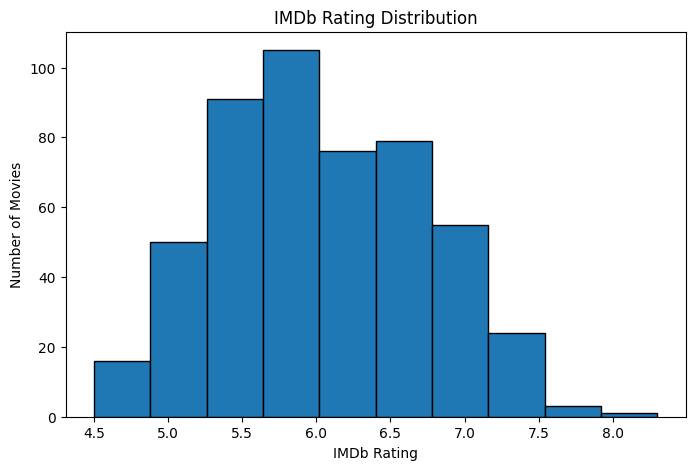

In [5]:
plt.figure(figsize=(8,5))

plt.hist(df["IMDb_Rating"], bins=10, edgecolor="black")

plt.title("IMDb Rating Distribution")
plt.xlabel("IMDb Rating")
plt.ylabel("Number of Movies")

plt.show()

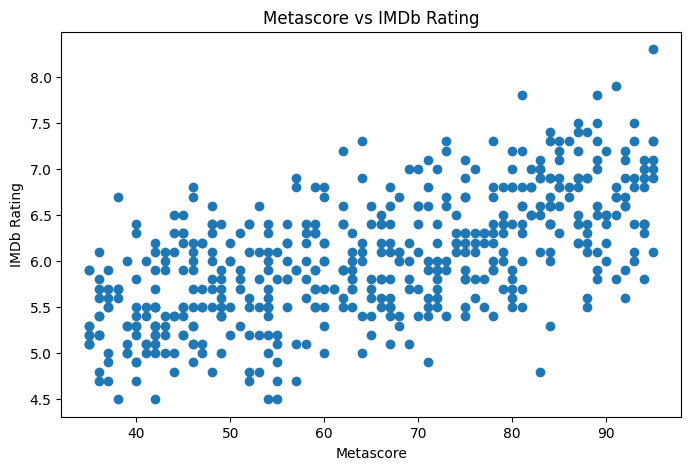

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(df["Metascore"], df["IMDb_Rating"])

plt.title("Metascore vs IMDb Rating")
plt.xlabel("Metascore")
plt.ylabel("IMDb Rating")

plt.show()

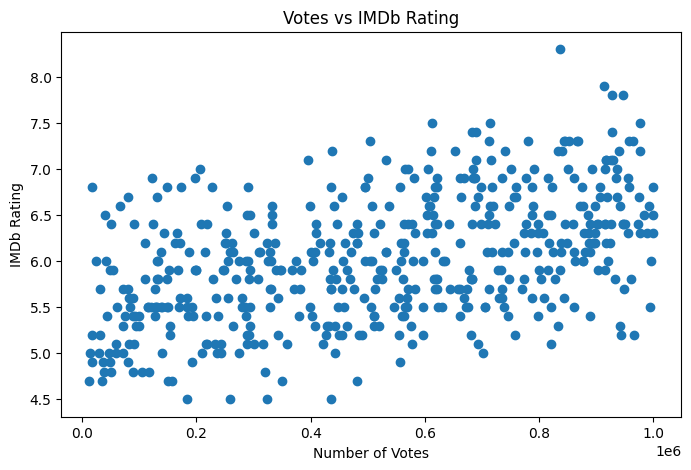

In [7]:
plt.figure(figsize=(8,5))

plt.scatter(df["Votes"], df["IMDb_Rating"])

plt.title("Votes vs IMDb Rating")
plt.xlabel("Number of Votes")
plt.ylabel("IMDb Rating")

plt.show()

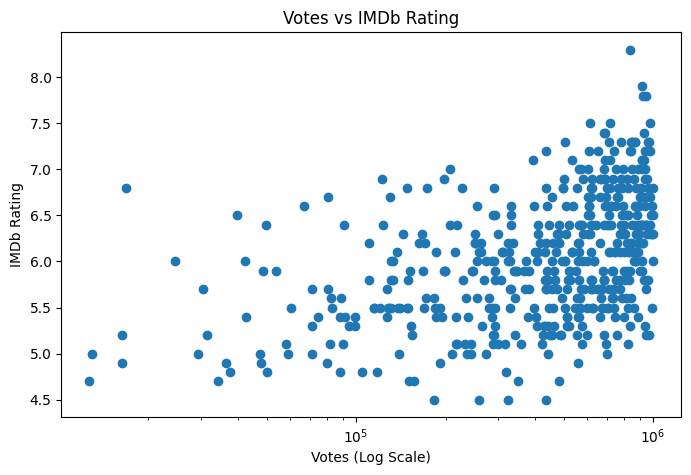

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(df["Votes"], df["IMDb_Rating"])

plt.xscale("log")

plt.title("Votes vs IMDb Rating")
plt.xlabel("Votes (Log Scale)")
plt.ylabel("IMDb Rating")

plt.show()

In [9]:
genre_rating = df.groupby("Genre")["IMDb_Rating"].mean()

print(genre_rating)

Genre
Action       5.848837
Adventure    5.973913
Animation    6.226531
Comedy       5.932143
Crime        6.282979
Drama        6.259574
Horror       5.884906
Romance      5.887931
Sci-Fi       6.119565
Thriller     5.916364
Name: IMDb_Rating, dtype: float64


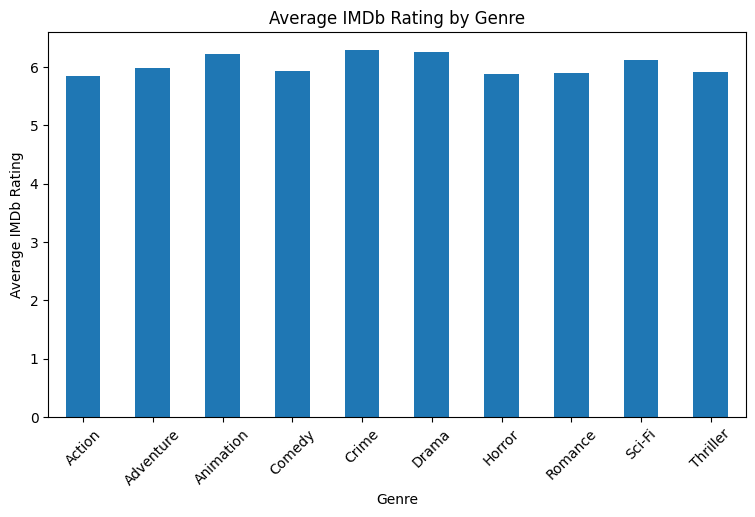

In [10]:
plt.figure(figsize=(9,5))

genre_rating.plot(kind="bar")

plt.title("Average IMDb Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average IMDb Rating")

plt.xticks(rotation=45)

plt.show()

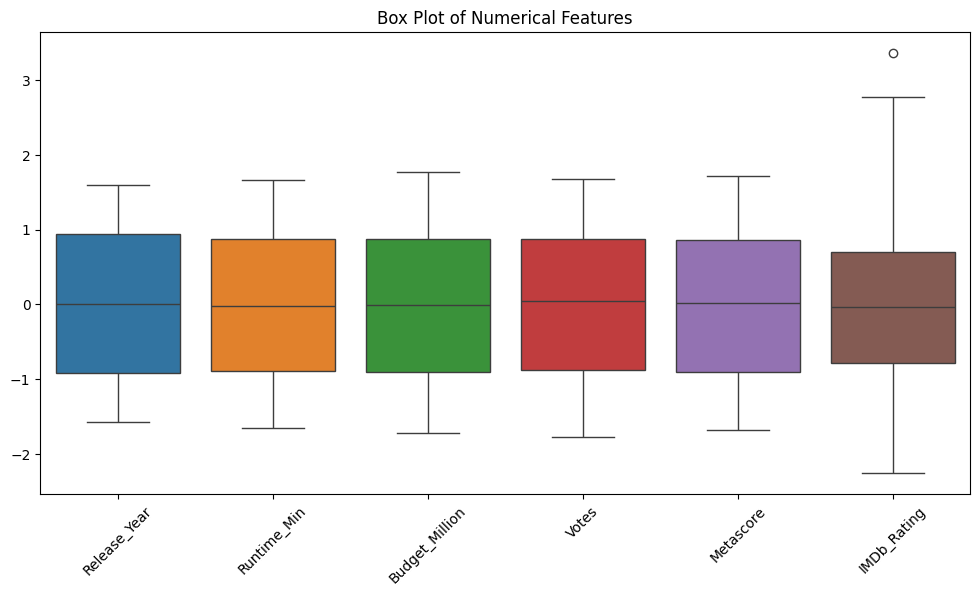

In [11]:
from sklearn.preprocessing import StandardScaler

numerical_columns = [
    "Release_Year",
    "Runtime_Min",
    "Budget_Million",
    "Votes",
    "Metascore",
    "IMDb_Rating"
]

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[numerical_columns])

scaled_df = pd.DataFrame(
    scaled_data,
    columns=numerical_columns
)

plt.figure(figsize=(12,6))

sns.boxplot(data=scaled_df)

plt.title("Box Plot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

In [12]:
X = df[[
    "Metascore",
    "Votes",
    "Runtime_Min",
    "Budget_Million"
]]

y = df["IMDb_Rating"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 4)
Testing data: (100, 4)


In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[5.89435635 7.1201535  6.37807251 6.26647626 5.48833084 6.26457953
 6.83530821 5.66005654 7.26400239 5.58629575]


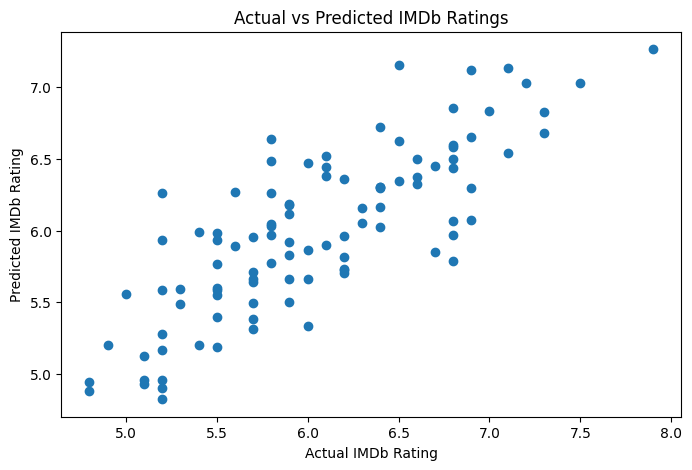

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual IMDb Rating")
plt.ylabel("Predicted IMDb Rating")

plt.title("Actual vs Predicted IMDb Ratings")

plt.show()

In [17]:
r2 = r2_score(y_test, y_pred)

print("R-squared:", r2)

R-squared: 0.6414819585175007


In [18]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Variable,Coefficient
0,Metascore,0.024194
1,Votes,0.000001
2,Runtime_Min,0.000904
3,Budget_Million,0.002222


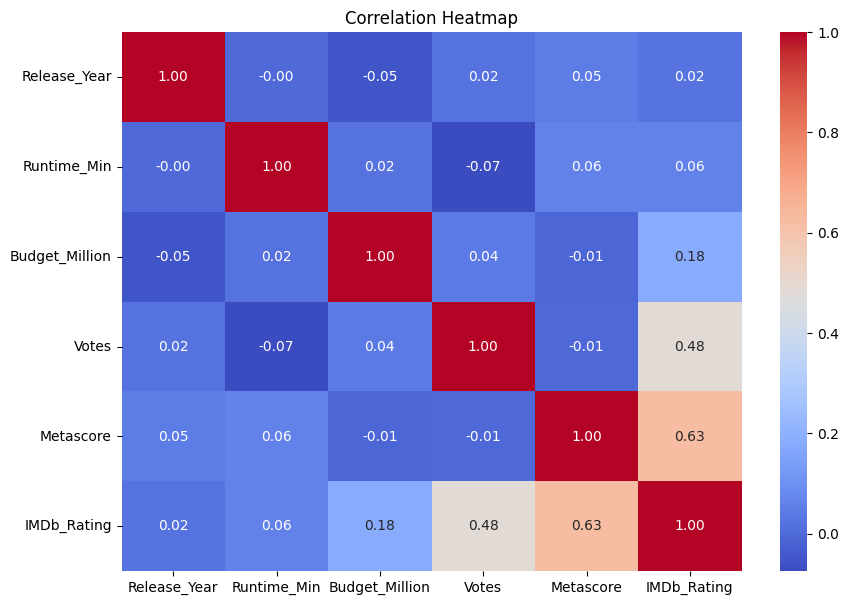

In [19]:
plt.figure(figsize=(10,7))

correlation = df[
    [
        "Release_Year",
        "Runtime_Min",
        "Budget_Million",
        "Votes",
        "Metascore",
        "IMDb_Rating"
    ]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()